# Serendipity Metric Evaluation — Kotkov SAC2018 Dataset
## T-NCD (Topological Normalised Compression Distance) vs Baseline Metrics

**Research question:** Does T-NCD better identify items that humans judge as serendipitous,  
compared to existing unexpectedness metrics?

**Dataset:** Kotkov et al. SAC2018 serendipity benchmark  
— real user judgements on serendipity across 8 label dimensions  
— 2,150 evaluated (user, movie) pairs · 481 users · 1678 movies

**Metrics compared:**
| Metric | Type | Reference |
|--------|------|-----------|
| EPD | Popularity-based unexpectedness | Ge et al. 2010 |
| Profile_Unexp (Adamopoulos) | Distance from user profile | Adamopoulos & Tuzhilin 2014 |
| Serendipity_GE | Unexpectedness × Relevance | Ge et al. 2010 |
| deltaG | Genre divergence (JSD) | Novel |
| **T-NCD** | **Topological barcode divergence** | **This work** |

**Evaluation protocol** (standard in serendipity literature):
1. Spearman ρ — rank correlation with human labels
2. AUC-ROC — discriminative power
3. Average Precision — precision-recall (handles label imbalance)
4. Precision@K — top-K retrieval quality
5. Lift per T-NCD regime — structural serendipity validation


In [ ]:
# scores_matched_genres = scores_matched.copy()
# scores_matched_genres['primary_genre'] = scores_matched_genres['mid'].apply(
#     lambda m: (movie_genres.get(int(m)) or ['Unknown'])[0])

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()
# fig.suptitle('Mean metric score by primary genre', fontweight='bold', fontsize=13)

# for ax, (mname, color) in zip(axes, METRIC_COLORS.items()):
#     genre_means = (scores_matched_genres.groupby('primary_genre')[mname]
#                    .agg(['mean','count'])
#                    .query('count >= 5')
#                    .sort_values('mean', ascending=False)
#                    .head(15))
#     ax.barh(genre_means.index, genre_means['mean'],
#             color=color, alpha=0.85, edgecolor='white')
#     ax.set_title(mname, fontweight='bold', fontsize=11)
#     ax.set_xlabel(f'Mean {mname} score')
#     ax.invert_yaxis()
#     ax.spines[['top','right']].set_visible(False)]

# axes[-1].set_visible(False)
# plt.tight_layout()
# plt.savefig('outputs/genre_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('✓ Genre analysis saved')

SyntaxError: unmatched ']' (2518824696.py, line 20)

In [ ]:
# scores_matched_genres = scores_matched.copy()
# scores_matched_genres['primary_genre'] = scores_matched_genres['mid'].apply(
#     lambda m: (movie_genres.get(int(m)) or ['Unknown'])[0])

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()
# fig.suptitle('Mean metric score by primary genre', fontweight='bold', fontsize=13)

# for ax, (mname, color) in zip(axes, METRIC_COLORS.items()):
#     genre_means = (scores_matched_genres.groupby('primary_genre')[mname]
#                    .agg(['mean','count'])
#                    .query('count >= 5')
#                    .sort_values('mean', ascending=False)
#                    .head(15))
#     ax.barh(genre_means.index, genre_means['mean'],
#             color=color, alpha=0.85, edgecolor='white')
#     ax.set_title(mname, fontweight='bold', fontsize=11)
#     ax.set_xlabel(f'Mean {mname} score')
#     ax.invert_yaxis()
#     ax.spines[['top','right']].set_visible(False)

# axes[-1].set_visible(False)
# plt.tight_layout()
# plt.savefig('outputs/genre_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('✓ Genre analysis saved')

In [ ]:
try:
    if 'scores_matched' in locals() or 'scores_matched' in globals():
        print("'scores_matched' is defined in the current kernel memory.")
    else:
        print("'scores_matched' is NOT defined in the current kernel memory.")
except NameError:
    print("'scores_matched' is NOT defined in the current kernel memory.")

## Cell 1 — Imports & Configuration

In [ ]:
!pip install ripser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.4 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=7170173b94a6f2a24195af63f2a3e55b9945e8a870bf86294ceb22e513b50d2d
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


In [ ]:
# !pip install ripser  # uncomment on first run

import os, warnings, logging, datetime, math, zlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import rel_entr
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import normalize
from sklearn.metrics import roc_auc_score, average_precision_score
from ripser import ripser
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

# ── PATH ──────────────────────────────────────────────────────
DATA_DIR = Path('/content/drive/MyDrive/serendipity-sac2018')
# DATA_DIR = Path('./data')   # ← change if running locally

# ── HYPERPARAMETERS ───────────────────────────────────────────
RELEVANCE_THRESHOLD = 3.5    # min rating to call a movie "liked"
TOP_K               = 10     # recommendation list length
MIN_HISTORY         = 5      # min liked movies required per user
TEMPORAL_HALF_LIFE  = 365    # days, for recency weighting
TCND_DELTA_MIN      = 0.05   # persistence noise floor
TCND_MAX_HISTORY    = 100    # cap history to keep barcodes tractable
LAMBDA_ALPHA        = 0.5    # weight: embed_unexp vs genre_unexp in composite

# ── LABEL COLUMNS ─────────────────────────────────────────────
# s_ = self-reported, m_ = method-reported
# _rel = relevant+unexpected, _find = discovery, _imp = impression, _rec = recency
ALL_LABELS     = ['s_ser_rel','s_ser_find','s_ser_imp','s_ser_rec',
                  'm_ser_rel','m_ser_find','m_ser_imp','m_ser_rec']
PRIMARY_LABELS = ['s_ser_rel', 'm_ser_rel']   # main comparison targets

print('✓ Config set')
print(f'  DATA_DIR  : {DATA_DIR}')
print(f'  TOP_K     : {TOP_K}')
print(f'  Labels    : {PRIMARY_LABELS}')


✓ Config set
  DATA_DIR  : /content/drive/MyDrive/serendipity-sac2018
  TOP_K     : 10
  Labels    : ['s_ser_rel', 'm_ser_rel']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 2 — Load Dataset Files

In [ ]:
def _check(p, name):
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}\nSet DATA_DIR correctly.")

# answers.csv — ground truth serendipity labels
_check(DATA_DIR / 'answers.csv', 'answers.csv')
answers = pd.read_csv(DATA_DIR / 'answers.csv',
                      dtype={'userId':'int32','movieId':'int32',
                             'rating':'float32','predictedRating':'float32'})
for col in ALL_LABELS:
    if col in answers.columns:
        answers[col] = answers[col].map(
            lambda x: True  if str(x).strip().upper() in ('TRUE','1','1.0')
                 else False if str(x).strip().upper() in ('FALSE','0','0.0')
                 else np.nan)

# movies.csv
_check(DATA_DIR / 'movies.csv', 'movies.csv')
movies = pd.read_csv(DATA_DIR / 'movies.csv', on_bad_lines='skip',
                     dtype={'movieId':'int32'})
# Genre list from comma-separated string
movies['genre_list'] = movies['genres'].fillna('').apply(
    lambda g: [x.strip() for x in g.split(',') if x.strip()])
movie_genres = movies.set_index('movieId')['genre_list'].to_dict()
movie_titles = movies.set_index('movieId')['title'].to_dict()

# training.csv (~10M rows)
_check(DATA_DIR / 'training.csv', 'training.csv')
print('Loading training.csv (~10 M rows)...')
training = pd.read_csv(DATA_DIR / 'training.csv',
                       dtype={'userId':'int32','movieId':'int32',
                              'rating':'float32','timestamp':'int64'})

# tag_genome.csv — filter to relevant movies only to save RAM
_check(DATA_DIR / 'tag_genome.csv', 'tag_genome.csv')
eval_users   = set(answers['userId'].unique())
eval_movies  = set(answers['movieId'].unique())
hist_movies  = set(training[training['userId'].isin(eval_users)]['movieId'].unique())
genome_movies = eval_movies | hist_movies

print(f'Loading tag_genome (filtering to {len(genome_movies):,} movies)...')
chunks = []
for chunk in pd.read_csv(DATA_DIR / 'tag_genome.csv', chunksize=500_000,
                          dtype={'movieId':'int32','relevance':'float32'}):
    chunks.append(chunk[chunk['movieId'].isin(genome_movies)])
tag_genome = pd.concat(chunks, ignore_index=True)

print(f'\nDataset summary:')
print(f'  answers.csv   : {len(answers):,} pairs | {answers["userId"].nunique()} users | {answers["movieId"].nunique()} movies')
print(f'  training.csv  : {len(training):,} ratings | {training["userId"].nunique():,} users')
print(f'  tag_genome    : {tag_genome["movieId"].nunique():,} movies | {tag_genome["tag"].nunique():,} tags')
print(f'  Label balance : s_ser_rel True={answers["s_ser_rel"].sum()} ({100*answers["s_ser_rel"].mean():.1f}%)')
print(f'                  m_ser_rel True={answers["m_ser_rel"].sum()} ({100*answers["m_ser_rel"].mean():.1f}%)')


Loading training.csv (~10 M rows)...
Loading tag_genome (filtering to 25,440 movies)...

Dataset summary:
  answers.csv   : 2,150 pairs | 481 users | 1678 movies
  training.csv  : 9,997,850 ratings | 104,661 users
  tag_genome    : 10,371 movies | 1,128 tags
  Label balance : s_ser_rel True=79 (3.7%)
                  m_ser_rel True=93 (4.3%)


## Cell 3 — Tag Genome Embeddings

In [ ]:
print('Building tag-genome embedding matrix...')
genome_pivot = (tag_genome
                .pivot(index='movieId', columns='tag', values='relevance')
                .fillna(0.0))

genome_movie_ids = np.array(genome_pivot.index, dtype=np.int32)
embedding_matrix = normalize(genome_pivot.values.astype(np.float32), norm='l2')
movie2idx = {mid: i for i, mid in enumerate(genome_movie_ids)}

print(f'✓ Embedding matrix : {embedding_matrix.shape[0]:,} movies × {embedding_matrix.shape[1]:,} tags (L2-normalised)')
print(f'  Eval movies covered by genome: {len(eval_movies & set(genome_movie_ids))}/{len(eval_movies)}')
print(f'  Missing: {len(eval_movies) - len(eval_movies & set(genome_movie_ids))} movies → will be NaN in genome-based metrics')

def get_vec(mid):
    idx = movie2idx.get(int(mid))
    return embedding_matrix[idx] if idx is not None else None

def get_vecs(mids):
    idxs = [movie2idx[m] for m in mids if int(m) in movie2idx]
    return embedding_matrix[idxs] if idxs else np.zeros((0, embedding_matrix.shape[1]))

def centroid(mids, weights=None):
    vecs = get_vecs(mids)
    if vecs.shape[0] == 0: return None
    if weights is not None:
        mask = [int(m) in movie2idx for m in mids]
        w = np.array(weights)[mask]; w /= w.sum()
        c = (vecs * w[:, None]).sum(axis=0)
    else:
        c = vecs.mean(axis=0)
    n = np.linalg.norm(c)
    return c / n if n > 0 else c

def cos_sim(a, b):
    if a is None or b is None: return np.nan
    return float(np.dot(a, b))


Building tag-genome embedding matrix...
✓ Embedding matrix : 10,371 movies × 1,128 tags (L2-normalised)
  Eval movies covered by genome: 1182/1678
  Missing: 496 movies → will be NaN in genome-based metrics


## Cell 4 — Build User Profiles

In [ ]:
"""
For each evaluation user we compute:
  profile_vec       : centroid of liked-movie embeddings
  profile_vec_time  : recency-weighted centroid (for temporal metrics)
  genre_dist        : normalised genre frequency distribution
"""

REFERENCE_TS = int(datetime.datetime(2017, 4, 1).timestamp())  # SAC2018 survey date

def temporal_weight(ts, ref=REFERENCE_TS, half_life=TEMPORAL_HALF_LIFE):
    days = max((ref - (ts/1000 if ts > 1e11 else ts)) / 86400, 0)
    return 2.0 ** (-days / half_life)

def genre_dist(mids):
    counts = defaultdict(int)
    for mid in mids:
        for g in movie_genres.get(int(mid), []):
            counts[g] += 1
    total = sum(counts.values())
    return {g: c/total for g,c in counts.items()} if total else {}

eval_training = training[training['userId'].isin(eval_users)].copy()
user_profiles = {}

for uid in tqdm(eval_users, desc='Building profiles'):
    hist = eval_training[(eval_training['userId'] == uid) &
                         (eval_training['rating'] >= RELEVANCE_THRESHOLD)]
    if len(hist) < MIN_HISTORY: continue
    mids = hist['movieId'].tolist()
    tss  = hist['timestamp'].tolist()
    weights = [temporal_weight(ts) for ts in tss]
    user_profiles[uid] = {
        'liked_ids':    mids,
        'timestamps':   tss,
        'profile_vec':  centroid(mids),
        'profile_time': centroid(mids, weights),
        'genre_dist':   genre_dist(mids),
        'n_history':    len(mids),
    }

print(f'\n✓ Profiles built for {len(user_profiles)} / {len(eval_users)} users')
hist_lens = [p['n_history'] for p in user_profiles.values()]
print(f'  History length : median={np.median(hist_lens):.0f}  mean={np.mean(hist_lens):.1f}  min={min(hist_lens)}  max={max(hist_lens)}')


Building profiles:   0%|          | 0/481 [00:00<?, ?it/s]


✓ Profiles built for 481 / 481 users
  History length : median=320  mean=392.7  min=30  max=2685


## Cell 5 — Metric Definitions

In [ ]:
# ── Popularity primitive (for EPD) ───────────────────────────
movie_pop = training['movieId'].value_counts().to_dict()
pop_rank  = {mid: r for r, mid in
             enumerate(sorted(movie_pop, key=movie_pop.get, reverse=True))}
max_rank  = max(pop_rank.values()) if pop_rank else 1
top200_pop = [mid for mid,_ in
              sorted(movie_pop.items(), key=lambda x: x[1], reverse=True)
              if mid in movie2idx][:200]
primitive_centroid = centroid(top200_pop)

# ── JSD helper ────────────────────────────────────────────────
def jsd(p_dict, q_dict):
    keys = set(p_dict) | set(q_dict)
    p = np.array([p_dict.get(k,0.) for k in keys])
    q = np.array([q_dict.get(k,0.) for k in keys])
    p = p/p.sum() if p.sum()>0 else p
    q = q/q.sum() if q.sum()>0 else q
    m = 0.5*(p+q)
    return float(np.clip(0.5*np.sum(rel_entr(p,m)) + 0.5*np.sum(rel_entr(q,m)), 0, 1))

# ── T-NCD barcode cache ───────────────────────────────────────
_barcode_cache = {}

def _distance_matrix(vecs):
    n = np.linalg.norm(vecs, axis=1, keepdims=True)
    v = vecs / np.where(n==0, 1e-10, n)
    return np.clip(1 - v @ v.T, 0, 2).astype(np.float64)

def _barcode(D, delta_min=TCND_DELTA_MIN):
    res = ripser(D, maxdim=1, distance_matrix=True)
    all_fin = [d for dgm in res['dgms'] for b,d in dgm if np.isfinite(d)]
    cap = (max(all_fin)+0.1) if all_fin else 1.1
    bars = []
    for dim, dgm in enumerate(res['dgms']):
        for b, d in dgm:
            d = cap if not np.isfinite(d) else d
            if d - b > delta_min:
                bars.append((dim, round(float(b),4), round(float(d),4)))
    return sorted(bars)

def _serialise(bars):
    return ';'.join(f'{d},{b},{e}' for d,b,e in bars).encode('utf-8')

def _ncd(x, y):
    cx=len(zlib.compress(x,9)); cy=len(zlib.compress(y,9))
    return (len(zlib.compress(x+y,9)) - min(cx,cy)) / max(cx,cy)

def _user_barcode(uid):
    if uid in _barcode_cache: return _barcode_cache[uid]
    p = user_profiles.get(uid)
    if p is None: return None, None
    vecs_list = [get_vec(m) for m in p['liked_ids'][:TCND_MAX_HISTORY]
                 if get_vec(m) is not None]
    if len(vecs_list) < 3: return None, None
    D = _distance_matrix(np.array(vecs_list))
    bars = _barcode(D)
    b = _serialise(bars)
    _barcode_cache[uid] = (bars, b)
    return bars, b

# ══════════════════════════════════════════════════════════════
# METRIC FUNCTIONS  — each returns float, NaN if unavailable
# ══════════════════════════════════════════════════════════════

def metric_epd(uid, mid, **kw):
    """EPD: distance from popularity centroid (Ge et al. 2010)."""
    v = get_vec(mid)
    if v is None or primitive_centroid is None: return np.nan
    return float(1 - cos_sim(v, primitive_centroid))

def metric_profile_unexp(uid, mid, **kw):
    """Adamopoulos & Tuzhilin 2014: distance from user taste centroid."""
    p = user_profiles.get(uid)
    if p is None or p['profile_vec'] is None: return np.nan
    v = get_vec(mid)
    if v is None: return np.nan
    return float(1 - cos_sim(v, p['profile_vec']))

def metric_serendipity_ge(uid, mid, rating=None, **kw):
    """Ge 2010 full serendipity: unexpectedness × relevance."""
    u = metric_profile_unexp(uid, mid)
    if np.isnan(u): return np.nan
    rel = 1.0 if (rating is None or rating >= RELEVANCE_THRESHOLD) else 0.0
    return float(u * rel)

def metric_deltaG(uid, mid, **kw):
    """Genre divergence: JSD between movie genre and user genre distribution."""
    p = user_profiles.get(uid)
    if p is None: return np.nan
    genres = movie_genres.get(int(mid), [])
    if not genres: return np.nan
    rec_dist = {g: 1/len(genres) for g in genres}
    if not p['genre_dist']: return np.nan
    return jsd(rec_dist, p['genre_dist'])

def metric_tcnd(uid, mid, **kw):
    """T-NCD: topological barcode divergence (this work). Returns raw distance.
    T-NCD(u,r) = NCD( B(Gu), B(G'u) )
    where B(.) is the persistence barcode serialised as bytes,
    and NCD uses zlib DEFLATE level-9.
    """
    _, bu = _user_barcode(uid)
    if bu is None: return np.nan
    v_r = get_vec(mid)
    if v_r is None: return np.nan
    p = user_profiles.get(uid)
    vecs = [get_vec(m) for m in p['liked_ids'][:TCND_MAX_HISTORY]
            if get_vec(m) is not None]
    if len(vecs) < 3: return np.nan
    extended = np.array(vecs + [v_r])
    bars_p = _barcode(_distance_matrix(extended))
    bu_p   = _serialise(bars_p)
    return float(np.clip(_ncd(bu, bu_p), 0, 1))

def metric_tcnd_inverted(uid, mid, **kw):
    """T-NCD inverted: 1.0 - raw T-NCD distance (for similarity-based evaluation)."""
    raw_tcnd = metric_tcnd(uid, mid, **kw)
    if np.isnan(raw_tcnd): return np.nan
    return 1.0 - raw_tcnd

def apply_tncd_relevance_wrapper(df, relevance_col='predictedRating', distance_col='T_NCD', tau_percentile=0.75):
    """
    Applies a dynamic, user-specific relevance gate to topological distance.

    Args:
        df: DataFrame containing candidate items for all users.
        relevance_col: Predicted relevance score from your base model.
        distance_col: The raw T-NCD distance calculated from the graph.
        tau_percentile: The cutoff percentile (0.75 means top 25% of items survive).
    """
    df = df.copy()

    # Ensure relevance_col exists and is numeric
    if relevance_col not in df.columns:
        print(f"Warning: Relevance column '{relevance_col}' not found. Skipping T_NCD_hybrid calculation.")
        df['T_NCD_hybrid'] = np.nan
        return df

    if not pd.api.types.is_numeric_dtype(df[relevance_col]):
        print(f"Warning: Relevance column '{relevance_col}' is not numeric. Skipping T_NCD_hybrid calculation.")
        df['T_NCD_hybrid'] = np.nan
        return df

    # 1. Calculate the dynamic user-specific tau threshold
    # For each user, find the Xth percentile of their predicted candidate relevance scores.
    # Filter out NaNs in relevance_col before calculating quantile per group
    user_tau = df.groupby('uid')[relevance_col].transform(
        lambda x: x.quantile(tau_percentile) if x.count() > 0 else np.nan
    )

    # 2. Apply the Relevance Gate: max(0, relevance - tau)
    # Any item falling below the user's tau threshold gets mathematically zeroed out.
    df['relevance_gate'] = np.maximum(0, df[relevance_col] - user_tau)

    # 3. Calculate the Hybrid T-NCD Score
    # We multiply the surviving relevance multiplier by the RAW distance.
    # Because we want maximum distance *given* relevance, HIGHER IS NOW BETTER.
    # Handle potential NaNs from distance_col
    df['T_NCD_hybrid'] = df['relevance_gate'] * df[distance_col].fillna(0)

    return df

METRICS = {
    'EPD':            metric_epd,
    'Profile_Unexp':  metric_profile_unexp,
    'Serendipity_GE': metric_serendipity_ge,
    'deltaG':         metric_deltaG,
    'T_NCD':          metric_tcnd,            # Raw T-NCD distance
    'T_NCD_inverted': metric_tcnd_inverted, # Inverted T-NCD for similarity evaluation
}
print(f'✓ {len(METRICS)} metrics defined: {list(METRICS)}')

✓ 6 metrics defined: ['EPD', 'Profile_Unexp', 'Serendipity_GE', 'deltaG', 'T_NCD', 'T_NCD_inverted']


## Cell 6 — Compute All Metric Scores

In [ ]:
print('Computing metric scores...')
rows = []
for _, row in tqdm(answers.iterrows(), total=len(answers), desc='Scoring pairs'):
    uid   = int(row['userId'])
    mid   = int(row['movieId'])
    rat   = float(row['rating']) if not pd.isna(row.get('rating', np.nan)) else None
    pred_rat = float(row['predictedRating']) if not pd.isna(row.get('predictedRating', np.nan)) else np.nan
    if uid not in user_profiles: continue
    rec = {'uid': uid, 'mid': mid, 'rating': rat, 'predictedRating': pred_rat}
    for mname, fn in METRICS.items():
        rec[mname] = fn(uid, mid, rating=rat)
    for lbl in ALL_LABELS:
        rec[lbl] = row.get(lbl, np.nan)
    rows.append(rec)

scores_df = pd.DataFrame(rows)

# Apply the T-NCD Relevance Wrapper to create the hybrid score
scores_df = apply_tncd_relevance_wrapper(
    scores_df,
    relevance_col='predictedRating',
    distance_col='T_NCD',
    tau_percentile=0.75
)

# --- New code for Harmonic Mean Ensemble ---
def min_max_scale(series):
    # Filter out NaNs before calculating min/max to avoid errors
    non_nan_series = series.dropna()
    if non_nan_series.empty:
        return series # Return original series if all NaNs
    s_min = non_nan_series.min()
    s_max = non_nan_series.max()
    if s_max == s_min: # Handle cases where all values are the same
        return series.apply(lambda x: 0.01 if pd.notna(x) else np.nan)
    # Scale to [0.01, 1.0]
    scaled_series = 0.99 * ((series - s_min) / (s_max - s_min)) + 0.01
    return scaled_series

# Use .copy() to avoid SettingWithCopyWarning
scores_df_copy = scores_df.copy()

# Create normalized columns, handling potential NaNs from scaling
# Ensure deltaG and T_NCD_hybrid are treated as numeric for min_max_scale
scores_df_copy['deltaG_norm'] = min_max_scale(scores_df_copy['deltaG'])
scores_df_copy['T_NCD_hybrid_norm'] = min_max_scale(scores_df_copy['T_NCD_hybrid'])

# Ensure that we only calculate Harmonic_T_NCD where both normalized metrics are valid numbers
valid_mask = scores_df_copy['deltaG_norm'].notna() & scores_df_copy['T_NCD_hybrid_norm'].notna()
scores_df_copy['Harmonic_T_NCD'] = np.nan # Initialize with NaN

numerator = 2 * scores_df_copy.loc[valid_mask, 'deltaG_norm'] * scores_df_copy.loc[valid_mask, 'T_NCD_hybrid_norm']
denominator = scores_df_copy.loc[valid_mask, 'deltaG_norm'] + scores_df_copy.loc[valid_mask, 'T_NCD_hybrid_norm']

scores_df_copy.loc[valid_mask, 'Harmonic_T_NCD'] = numerator / denominator

scores_df = scores_df_copy # Update the original scores_df

# ── Coverage report ───────────────────────────────────────────
print(f'\n✓ scores_df: {len(scores_df):,} rows')
print(f'\nCoverage (valid scores / total pairs):')
# Include the new T_NCD_hybrid and Harmonic_T_NCD in the coverage report
ALL_METRICS_FOR_COVERAGE = list(METRICS.keys()) + ['T_NCD_hybrid', 'Harmonic_T_NCD']
ALL_METRICS_FOR_EVAL = ALL_METRICS_FOR_COVERAGE # Make them consistent

for m in ALL_METRICS_FOR_COVERAGE:
    n = scores_df[m].notna().sum()
    pct = 100*n/len(scores_df)
    print(f'  {m:<20}: {n:,} / {len(scores_df):,}  ({pct:.1f}%)')

# ── IMPORTANT: create matched subset for fair comparison ─────
# Only pairs where ALL relevant metrics have valid scores
genome_cols = ['EPD','Profile_Unexp','Serendipity_GE','deltaG','T_NCD', 'T_NCD_inverted', 'T_NCD_hybrid', 'Harmonic_T_NCD']
matched_mask = scores_df[genome_cols].notna().all(axis=1)
scores_matched = scores_df[matched_mask].copy()
print(f'\nMatched subset (all metrics valid): {len(scores_matched):,} pairs')
print(f'Label balance in matched subset:')
for lbl in PRIMARY_LABELS:
    rate = scores_matched[lbl].mean()
    print(f'  {lbl}: {scores_matched[lbl].sum():.0f} True ({100*rate:.1f}%)')

Computing metric scores...


Scoring pairs:   0%|          | 0/2150 [00:00<?, ?it/s]


✓ scores_df: 2,150 rows

Coverage (valid scores / total pairs):
  EPD                 : 1,584 / 2,150  (73.7%)
  Profile_Unexp       : 1,584 / 2,150  (73.7%)
  Serendipity_GE      : 1,584 / 2,150  (73.7%)
  deltaG              : 2,101 / 2,150  (97.7%)
  T_NCD               : 1,584 / 2,150  (73.7%)
  T_NCD_inverted      : 1,584 / 2,150  (73.7%)
  T_NCD_hybrid        : 2,130 / 2,150  (99.1%)
  Harmonic_T_NCD      : 2,081 / 2,150  (96.8%)

Matched subset (all metrics valid): 1,572 pairs
Label balance in matched subset:
  s_ser_rel: 58 True (3.7%)
  m_ser_rel: 78 True (5.0%)


## Cell 7 — Pair-Level Evaluation Against Ground Truth

In [ ]:
R"""
Standard serendipity metric evaluation protocol:
  - Spearman ρ : rank correlation (non-parametric, handles non-normality)
  - AUC-ROC    : discriminative power regardless of threshold
  - Avg Precision : area under precision-recall curve (better for imbalanced labels)
  - Precision@K : top-K precision

All computed on the matched subset so metrics are directly comparable.
"""

def eval_metric_vs_label(scores, labels, k=TOP_K):
    mask = scores.notna() & labels.notna()
    s = scores[mask].values.astype(float)
    l = labels[mask].values.astype(float)
    if len(s) < 10 or l.sum() == 0 or l.sum() == len(l):
        return {k_: np.nan for k_ in ['n','spearman','auc_roc','avg_precision',f'P@{k}']}
    sp, _ = spearmanr(s, l)
    auc   = roc_auc_score(l, s)
    ap    = average_precision_score(l, s)
    topk  = l[np.argsort(s)[::-1][:k]].mean()
    return {'n': int(mask.sum()), 'spearman': round(sp,4),
            'auc_roc': round(auc,4), 'avg_precision': round(ap,4),
            f'P@{k}': round(topk,4)}

print('Running pair-level evaluation on matched subset...')
eval_rows = []

# Include all metrics, including the new hybrid T-NCD and Harmonic_T_NCD
ALL_METRICS_FOR_EVAL = list(METRICS.keys()) + ['T_NCD_hybrid', 'Harmonic_T_NCD']

for mname in ALL_METRICS_FOR_EVAL:
    for lbl in ALL_LABELS:
        if lbl not in scores_matched.columns: continue
        stats = eval_metric_vs_label(scores_matched[mname], scores_matched[lbl])
        eval_rows.append({'metric': mname, 'label': lbl, **stats})

eval_df = pd.DataFrame(eval_rows)

# Show primary labels
print('── Primary label results ──')
print(eval_df[eval_df['label'].isin(PRIMARY_LABELS)].to_string(index=False))

Running pair-level evaluation on matched subset...
── Primary label results ──
        metric     label    n  spearman  auc_roc  avg_precision  P@10
           EPD s_ser_rel 1572    0.0197   0.5301         0.0443   0.0
           EPD m_ser_rel 1572   -0.0179   0.4762         0.0456   0.0
 Profile_Unexp s_ser_rel 1572    0.0087   0.5133         0.0428   0.1
 Profile_Unexp m_ser_rel 1572   -0.0082   0.4892         0.0479   0.1
Serendipity_GE s_ser_rel 1572    0.0074   0.5113         0.0428   0.1
Serendipity_GE m_ser_rel 1572   -0.0050   0.4934         0.0483   0.1
        deltaG s_ser_rel 1572    0.0390   0.5597         0.0824   0.2
        deltaG m_ser_rel 1572    0.0401   0.5533         0.0694   0.1
         T_NCD s_ser_rel 1572   -0.0140   0.4785         0.0400   0.1
         T_NCD m_ser_rel 1572    0.0142   0.5189         0.0570   0.1
T_NCD_inverted s_ser_rel 1572    0.0140   0.5215         0.0389   0.1
T_NCD_inverted m_ser_rel 1572   -0.0142   0.4811         0.0478   0.1
  T_NCD_hyb

## Cell 8 — List-Level Evaluation (Per-User Ranking)

In [ ]:
R"""
Real deployment scenario: for each user, rank their eval movies by metric score.
Precision@K measures how many serendipitous movies land in the top-K.
"""

def precision_at_k_per_user(df, metric_col, label_col, k=TOP_K):
    precs = []
    for uid, grp in df.groupby('uid'):
        g = grp[[metric_col, label_col]].dropna()
        if len(g) == 0: continue
        # For T_NCD_inverted and T_NCD_hybrid, higher scores are better, so sort descending.
        # This function implicitly sorts descending as it calls nlargest.
        topk = g.nlargest(k, metric_col)
        precs.append(topk[label_col].astype(float).mean())
    return np.mean(precs) if precs else np.nan

print(f'Per-user Precision@{TOP_K} (list-level):')
list_rows = []

# Include all metrics, including the new hybrid T-NCD and Harmonic_T_NCD
ALL_METRICS_FOR_EVAL = list(METRICS.keys()) + ['T_NCD_hybrid', 'Harmonic_T_NCD']

for mname in ALL_METRICS_FOR_EVAL:
    for lbl in PRIMARY_LABELS:
        if lbl not in scores_matched.columns: continue
        p = precision_at_k_per_user(scores_matched, mname, lbl)
        list_rows.append({'metric': mname, 'label': lbl, f'P@{TOP_K}_list': round(p,4)})

list_df = pd.DataFrame(list_rows)
print(list_df.to_string(index=False))

Per-user Precision@10 (list-level):
        metric     label  P@10_list
           EPD s_ser_rel     0.0328
           EPD m_ser_rel     0.0483
 Profile_Unexp s_ser_rel     0.0328
 Profile_Unexp m_ser_rel     0.0483
Serendipity_GE s_ser_rel     0.0328
Serendipity_GE m_ser_rel     0.0483
        deltaG s_ser_rel     0.0328
        deltaG m_ser_rel     0.0483
         T_NCD s_ser_rel     0.0328
         T_NCD m_ser_rel     0.0483
T_NCD_inverted s_ser_rel     0.0328
T_NCD_inverted m_ser_rel     0.0483
  T_NCD_hybrid s_ser_rel     0.0328
  T_NCD_hybrid m_ser_rel     0.0483
Harmonic_T_NCD s_ser_rel     0.0328
Harmonic_T_NCD m_ser_rel     0.0483


In [ ]:
R"""
Real deployment scenario: for each user, rank their eval movies by metric score.
Precision@K measures how many serendipitous movies land in the top-K.
"""

def precision_at_k_per_user(df, metric_col, label_col, k=TOP_K):
    precs = []
    for uid, grp in df.groupby('uid'):
        g = grp[[metric_col, label_col]].dropna()
        if len(g) == 0: continue
        # For T_NCD_inverted and T_NCD_hybrid, higher scores are better, so sort descending.
        # This function implicitly sorts descending as it calls nlargest.
        topk = g.nlargest(k, metric_col)
        precs.append(topk[label_col].astype(float).mean())
    return np.mean(precs) if precs else np.nan

print(f'Per-user Precision@{TOP_K} (list-level):')
list_rows = []

# Include all metrics, including the new hybrid T-NCD and Harmonic_T_NCD
ALL_METRICS_FOR_EVAL = list(METRICS.keys()) + ['T_NCD_hybrid', 'Harmonic_T_NCD']

for mname in ALL_METRICS_FOR_EVAL:
    for lbl in PRIMARY_LABELS:
        if lbl not in scores_matched.columns: continue
        p = precision_at_k_per_user(scores_matched, mname, lbl)
        list_rows.append({'metric': mname, 'label': lbl, f'P@{TOP_K}_list': round(p,4)})

list_df = pd.DataFrame(list_rows)
print(list_df.to_string(index=False))

Per-user Precision@10 (list-level):
        metric     label  P@10_list
           EPD s_ser_rel     0.0328
           EPD m_ser_rel     0.0483
 Profile_Unexp s_ser_rel     0.0328
 Profile_Unexp m_ser_rel     0.0483
Serendipity_GE s_ser_rel     0.0328
Serendipity_GE m_ser_rel     0.0483
        deltaG s_ser_rel     0.0328
        deltaG m_ser_rel     0.0483
         T_NCD s_ser_rel     0.0328
         T_NCD m_ser_rel     0.0483
T_NCD_inverted s_ser_rel     0.0328
T_NCD_inverted m_ser_rel     0.0483
  T_NCD_hybrid s_ser_rel     0.0328
  T_NCD_hybrid m_ser_rel     0.0483
Harmonic_T_NCD s_ser_rel     0.0328
Harmonic_T_NCD m_ser_rel     0.0483


In [ ]:
R"""
Real deployment scenario: for each user, rank their eval movies by metric score.
Precision@K measures how many serendipitous movies land in the top-K.
"""

def precision_at_k_per_user(df, metric_col, label_col, k=TOP_K):
    precs = []
    for uid, grp in df.groupby('uid'):
        g = grp[[metric_col, label_col]].dropna()
        if len(g) == 0: continue
        # For T_NCD_inverted and T_NCD_hybrid, higher scores are better, so sort descending.
        # This function implicitly sorts descending as it calls nlargest.
        topk = g.nlargest(k, metric_col)
        precs.append(topk[label_col].astype(float).mean())
    return np.mean(precs) if precs else np.nan

print(f'Per-user Precision@{TOP_K} (list-level):')
list_rows = []

# Include all metrics, including the new hybrid T-NCD and Harmonic_T_NCD
ALL_METRICS_FOR_EVAL = list(METRICS.keys()) + ['T_NCD_hybrid', 'Harmonic_T_NCD']

for mname in ALL_METRICS_FOR_EVAL:
    for lbl in PRIMARY_LABELS:
        if lbl not in scores_matched.columns: continue
        p = precision_at_k_per_user(scores_matched, mname, lbl)
        list_rows.append({'metric': mname, 'label': lbl, f'P@{TOP_K}_list': round(p,4)})

list_df = pd.DataFrame(list_rows)
print(list_df.to_string(index=False))

Per-user Precision@10 (list-level):
        metric     label  P@10_list
           EPD s_ser_rel     0.0328
           EPD m_ser_rel     0.0483
 Profile_Unexp s_ser_rel     0.0328
 Profile_Unexp m_ser_rel     0.0483
Serendipity_GE s_ser_rel     0.0328
Serendipity_GE m_ser_rel     0.0483
        deltaG s_ser_rel     0.0328
        deltaG m_ser_rel     0.0483
         T_NCD s_ser_rel     0.0328
         T_NCD m_ser_rel     0.0483
T_NCD_inverted s_ser_rel     0.0328
T_NCD_inverted m_ser_rel     0.0483
  T_NCD_hybrid s_ser_rel     0.0328
  T_NCD_hybrid m_ser_rel     0.0483
Harmonic_T_NCD s_ser_rel     0.0328
Harmonic_T_NCD m_ser_rel     0.0483


In [ ]:
R"""
Real deployment scenario: for each user, rank their eval movies by metric score.
Precision@K measures how many serendipitous movies land in the top-K.
"""

def precision_at_k_per_user(df, metric_col, label_col, k=TOP_K):
    precs = []
    for uid, grp in df.groupby('uid'):
        g = grp[[metric_col, label_col]].dropna()
        if len(g) == 0: continue
        # For T_NCD_inverted and T_NCD_hybrid, higher scores are better, so sort descending.
        # This function implicitly sorts descending as it calls nlargest.
        topk = g.nlargest(k, metric_col)
        precs.append(topk[label_col].astype(float).mean())
    return np.mean(precs) if precs else np.nan

print(f'Per-user Precision@{TOP_K} (list-level):')
list_rows = []

# Include all metrics, including the new hybrid T-NCD and Harmonic_T_NCD
ALL_METRICS_FOR_EVAL = list(METRICS.keys()) + ['T_NCD_hybrid', 'Harmonic_T_NCD']

for mname in ALL_METRICS_FOR_EVAL:
    for lbl in PRIMARY_LABELS:
        if lbl not in scores_matched.columns: continue
        p = precision_at_k_per_user(scores_matched, mname, lbl)
        list_rows.append({'metric': mname, 'label': lbl, f'P@{TOP_K}_list': round(p,4)})

list_df = pd.DataFrame(list_rows)
print(list_df.to_string(index=False))

Per-user Precision@10 (list-level):
        metric     label  P@10_list
           EPD s_ser_rel     0.0328
           EPD m_ser_rel     0.0483
 Profile_Unexp s_ser_rel     0.0328
 Profile_Unexp m_ser_rel     0.0483
Serendipity_GE s_ser_rel     0.0328
Serendipity_GE m_ser_rel     0.0483
        deltaG s_ser_rel     0.0328
        deltaG m_ser_rel     0.0483
         T_NCD s_ser_rel     0.0328
         T_NCD m_ser_rel     0.0483
T_NCD_inverted s_ser_rel     0.0328
T_NCD_inverted m_ser_rel     0.0483
  T_NCD_hybrid s_ser_rel     0.0328
  T_NCD_hybrid m_ser_rel     0.0483
Harmonic_T_NCD s_ser_rel     0.0328
Harmonic_T_NCD m_ser_rel     0.0483


## Cell 9 — Summary Comparison Table (Paper Table)

In [ ]:
R"""
The table that goes in the paper.
Averaged over s_ser_rel and m_ser_rel (primary labels).
Metric rows ordered from classical to topological.
"""

summary = (eval_df[eval_df['label'].isin(PRIMARY_LABELS)]
           .groupby('metric')[['spearman','auc_roc','avg_precision',f'P@{TOP_K}']]
           .mean().round(4))

# Add list-level P@K
pk_avg = list_df.groupby('metric')[f'P@{TOP_K}_list'].mean().round(4)
summary = summary.join(pk_avg)

# Order metrics logically
order = [m for m in ['EPD','Profile_Unexp','Serendipity_GE','deltaG','T_NCD', 'T_NCD_inverted', 'T_NCD_hybrid', 'Harmonic_T_NCD']
         if m in summary.index]
summary = summary.reindex(order)
summary.columns = ['Spearman ρ','AUC-ROC','Avg Precision',f'P@{TOP_K}(pair)',f'P@{TOP_K}(list)']
summary.index.name = 'Metric'

print('='*72)
print('SERENDIPITY METRIC COMPARISON — KOTKOV SAC2018')
print(f'(averaged over {PRIMARY_LABELS}, matched subset)')
print('='*72)
print(summary.to_string())
print('='*72)

print('\nBest per criterion:')
for col in summary.columns:
    best = summary[col].idxmax()
    val  = summary[col].max()
    flag = ' ← T-NCD wins' if best == 'T_NCD' else ''
    print(f'  {col:<20}: {best} = {val:.4f}{flag}')

summary.to_csv('/content/drive/MyDrive/serendipity-sac2018/outputs/summary_table.csv')

SERENDIPITY METRIC COMPARISON — KOTKOV SAC2018
(averaged over ['s_ser_rel', 'm_ser_rel'], matched subset)
                Spearman ρ  AUC-ROC  Avg Precision  P@10(pair)  P@10(list)
Metric                                                                    
EPD                 0.0009   0.5032         0.0450        0.00      0.0406
Profile_Unexp       0.0002   0.5012         0.0454        0.10      0.0406
Serendipity_GE      0.0012   0.5024         0.0456        0.10      0.0406
deltaG              0.0396   0.5565         0.0759        0.15      0.0406
T_NCD               0.0001   0.4987         0.0485        0.10      0.0406
T_NCD_inverted     -0.0001   0.5013         0.0434        0.10      0.0406
T_NCD_hybrid        0.0140   0.5155         0.0464        0.00      0.0406
Harmonic_T_NCD      0.0376   0.5556         0.0522        0.00      0.0406

Best per criterion:
  Spearman ρ          : deltaG = 0.0396
  AUC-ROC             : deltaG = 0.5565
  Avg Precision       : deltaG = 0.0759
  P

## Cell 10 — T-NCD Regime Analysis

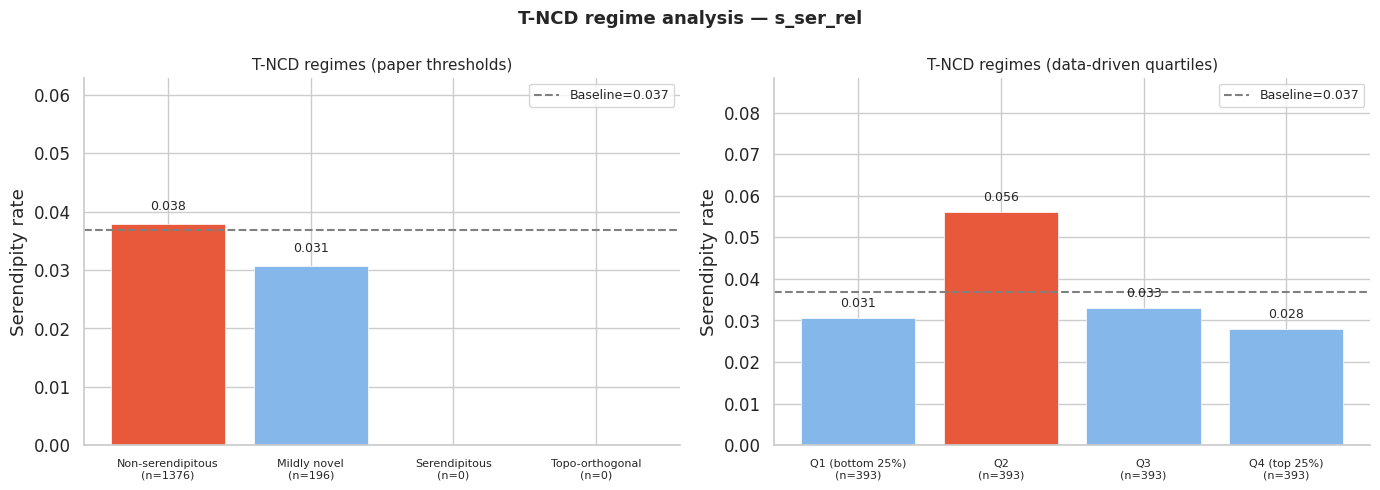


── Regime table (s_ser_rel) ──
  Baseline serendipity rate: 0.0369
  Regime                         N     Rate     Lift
  ----------------------------------------------------
  Non-serendipitous           1376   0.0378    1.02x
  Mildly novel                 196   0.0306    0.83x
  Serendipitous                  0   —        —
  Topo-orthogonal                0   —        —


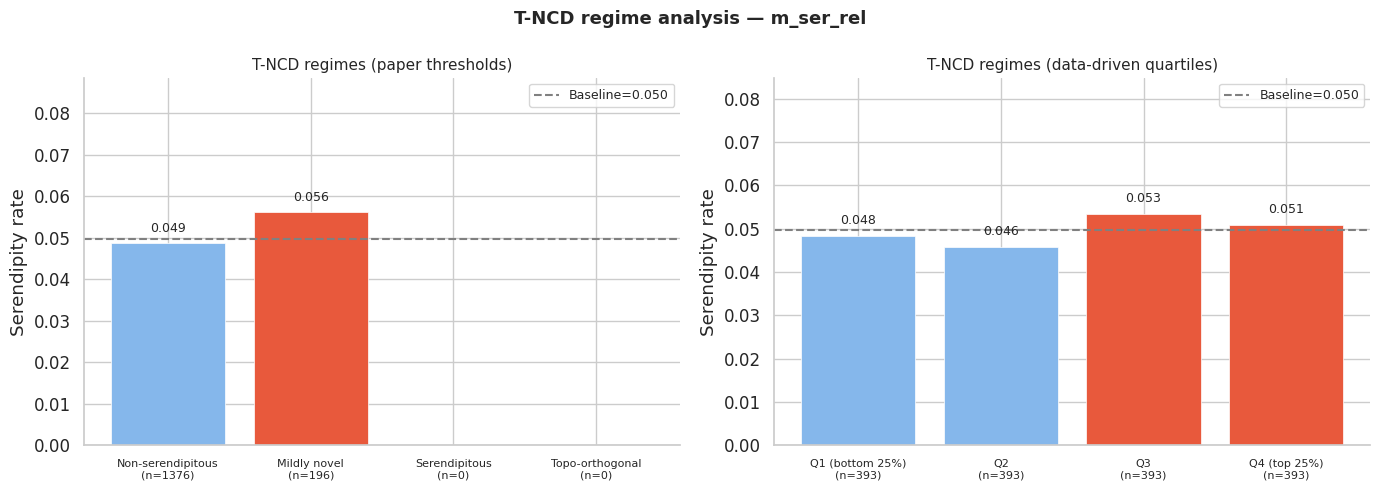


── Regime table (m_ser_rel) ──
  Baseline serendipity rate: 0.0496
  Regime                         N     Rate     Lift
  ----------------------------------------------------
  Non-serendipitous           1376   0.0487    0.98x
  Mildly novel                 196   0.0561    1.13x
  Serendipitous                  0   —        —
  Topo-orthogonal                0   —        —



In [ ]:
"""
Key validation for T-NCD: items in higher-score regimes should have
higher human serendipity rates. This tests whether the topological
thresholds from the paper (0.15 / 0.40 / 0.75) are meaningful.

If higher regimes have higher serendipity rates → T-NCD is calibrated.
If not → thresholds need empirical recalibration from this dataset.
"""

os.makedirs('outputs', exist_ok=True)

for lbl in PRIMARY_LABELS:
    df = scores_matched[['T_NCD', lbl, 'rating']].dropna()
    baseline = df[lbl].mean()

    regimes = [
        ('Non-serendipitous',   0.00, 0.15),
        ('Mildly novel',        0.15, 0.40),
        ('Serendipitous',       0.40, 0.75),
        ('Topo-orthogonal',     0.75, 1.01),
    ]

    # Also compute data-driven quartile regimes
    p25, p50, p75 = df['T_NCD'].quantile([0.25,0.50,0.75])
    quartile_regimes = [
        ('Q1 (bottom 25%)', 0,   p25),
        ('Q2',              p25, p50),
        ('Q3',              p50, p75),
        ('Q4 (top 25%)',    p75, 1.01),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'T-NCD regime analysis — {lbl}', fontweight='bold', fontsize=13)

    for ax, regs, title_sfx in [(axes[0], regimes, 'paper thresholds'),
                                 (axes[1], quartile_regimes, 'data-driven quartiles')]:
        names, rates, ns = [], [], []
        for name, lo, hi in regs:
            sub = df[(df['T_NCD'] >= lo) & (df['T_NCD'] < hi)]
            n = len(sub)
            rate = sub[lbl].mean() if n > 0 else np.nan
            names.append(f'{name}\n(n={n})')
            rates.append(rate if not np.isnan(rate) else 0)
            ns.append(n)

        colors = ['#85B7EB' if r <= baseline else '#E8593C' for r in rates]
        bars = ax.bar(names, rates, color=colors, edgecolor='white', linewidth=0.5)
        ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.5,
                   label=f'Baseline={baseline:.3f}')
        ax.set_ylabel('Serendipity rate')
        ax.set_title(f'T-NCD regimes ({title_sfx})', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_ylim(0, max(rates)*1.4 + 0.01)
        for bar, rate in zip(bars, rates):
            if rate > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                        f'{rate:.3f}', ha='center', va='bottom', fontsize=9)
        ax.tick_params(axis='x', labelsize=8)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'outputs/regime_analysis_{lbl}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print table
    print(f'\n── Regime table ({lbl}) ──')
    print(f'  Baseline serendipity rate: {baseline:.4f}')
    print(f'  {"Regime":<25} {"N":>6} {"Rate":>8} {"Lift":>8}')
    print('  ' + '-'*52)
    for name, lo, hi in regimes:
        sub = df[(df['T_NCD'] >= lo) & (df['T_NCD'] < hi)]
        n = len(sub)
        if n == 0:
            print(f'  {name:<25} {n:>6}   —        —')
            continue
        rate = sub[lbl].mean()
        lift = rate / baseline if baseline > 0 else np.nan
        print(f'  {name:<25} {n:>6} {rate:>8.4f} {lift:>7.2f}x')
print()


## Cell 11 — AUC-ROC Comparison Plots

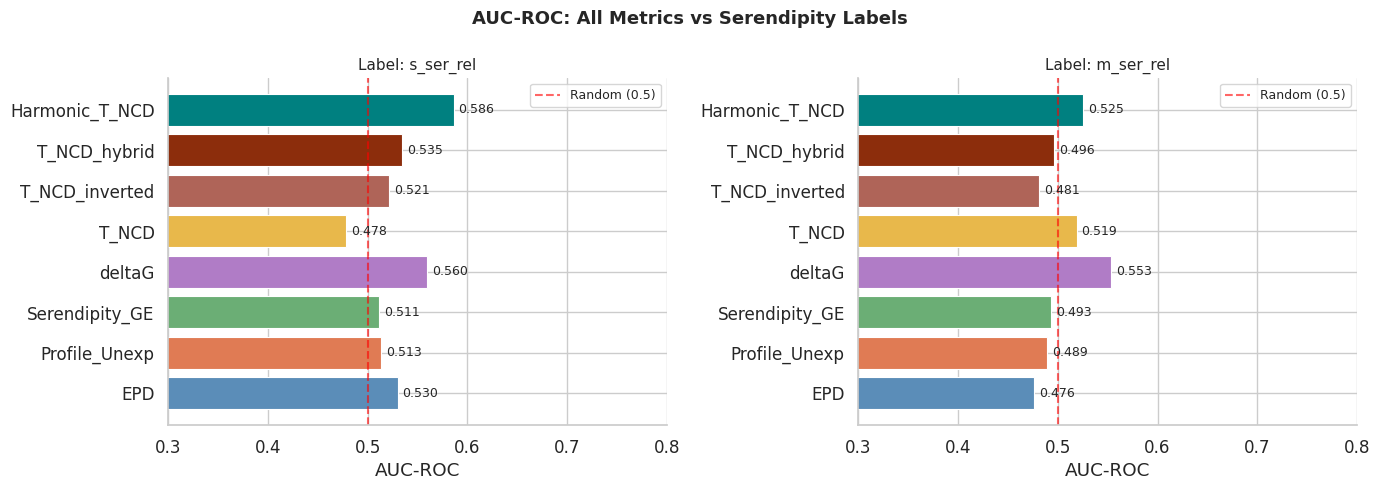

✓ AUC-ROC plot saved


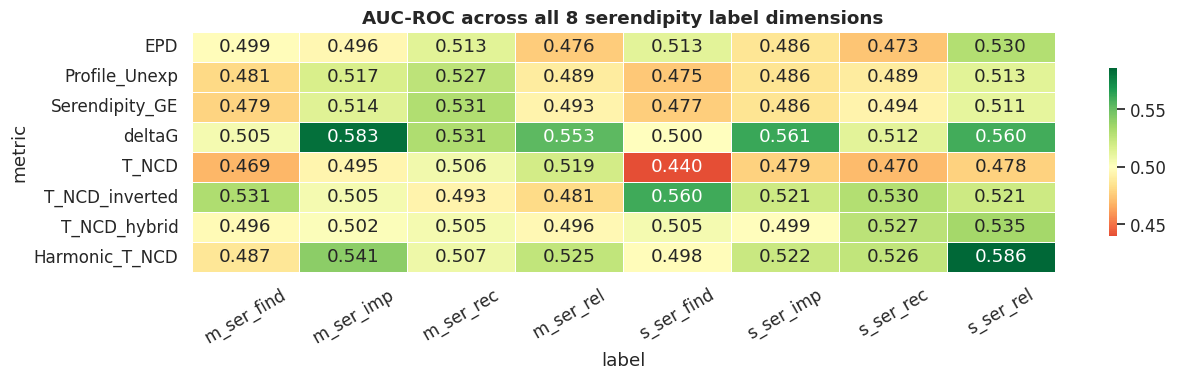

✓ Full label heatmap saved


In [ ]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

METRIC_COLORS = {
    'EPD':            '#5B8DB8',
    'Profile_Unexp':  '#E07B54',
    'Serendipity_GE': '#6BAE75',
    'deltaG':         '#B07CC6',
    'T_NCD':          '#E8B84B',
    'T_NCD_inverted': '#AF6458', # New color for inverted T-NCD
    'T_NCD_hybrid':   '#8C2D0C', # New color for hybrid T-NCD
    'Harmonic_T_NCD':   '#008080', # A new distinct color for the ensemble
}

# ── Plot 1: AUC-ROC per label ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AUC-ROC: All Metrics vs Serendipity Labels', fontweight='bold', fontsize=13)

for ax, lbl in zip(axes, PRIMARY_LABELS):
    sub = eval_df[eval_df['label'] == lbl].dropna(subset=['auc_roc'])
    sub = sub[sub['metric'].isin(METRIC_COLORS.keys())] # Use METRIC_COLORS keys to filter
    bars = ax.barh(sub['metric'], sub['auc_roc'],
                   color=[METRIC_COLORS.get(m,'#999') for m in sub['metric']],
                   edgecolor='white', linewidth=0.8)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Random (0.5)')
    ax.set_xlim(0.3, 0.8)
    ax.set_xlabel('AUC-ROC')
    ax.set_title(f'Label: {lbl}', fontsize=11)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, sub['auc_roc']):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/auc_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ AUC-ROC plot saved')

# ── Plot 2: all 8 labels heatmap ─────────────────────────────
pivot_auc = (eval_df[eval_df['metric'].isin(METRIC_COLORS.keys())] # Use METRIC_COLORS keys to filter
             .pivot(index='metric', columns='label', values='auc_roc')
             .reindex(order)) # 'order' now includes new metrics from Cell 9
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_auc, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0.5, linewidths=0.5, cbar_kws={'shrink':0.7})
ax.set_title('AUC-ROC across all 8 serendipity label dimensions', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('outputs/auc_all_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Full label heatmap saved')

In [ ]:
METRIC_COLORS = {
    'EPD':            '#5B8DB8',
    'Profile_Unexp':  '#E07B54',
    'Serendipity_GE': '#6BAE75',
    'deltaG':         '#B07CC6',
    'T_NCD':          '#E8B84B',
    'T_NCD_inverted': '#AF6458', # New color for inverted T-NCD
    'T_NCD_hybrid':   '#8C2D0C', # New color for hybrid T-NCD
    'Harmonic_T_NCD': '#008080', # Add Harmonic_T_NCD with its specific color
}

# ── Data for Plot 1: AUC-ROC per label ────────────────────────────────
print('AUC-ROC: All Metrics vs Serendipity Labels (Primary Labels)')
for lbl in PRIMARY_LABELS:
    sub = eval_df[eval_df['label'] == lbl].dropna(subset=['auc_roc'])
    sub = sub[sub['metric'].isin(METRIC_COLORS.keys())] # Use METRIC_COLORS keys to filter
    print(f'\nLabel: {lbl}')
    display(sub[['metric', 'auc_roc']].sort_values(by='auc_roc', ascending=False).reset_index(drop=True))

# ── Data for Plot 2: all 8 labels heatmap ─────────────────────────────
pivot_auc = (eval_df[eval_df['metric'].isin(METRIC_COLORS.keys())] # Use METRIC_COLORS keys to filter
             .pivot(index='metric', columns='label', values='auc_roc')
             .reindex(order))
print('\nAUC-ROC across all 8 serendipity label dimensions (Heatmap Data):')
display(pivot_auc)

AUC-ROC: All Metrics vs Serendipity Labels (Primary Labels)

Label: s_ser_rel


,metric,auc_roc
0,Harmonic_T_NCD,0.5861
1,deltaG,0.5597
2,T_NCD_hybrid,0.5346
3,EPD,0.5301
4,T_NCD_inverted,0.5215
5,Profile_Unexp,0.5133
6,Serendipity_GE,0.5113
7,T_NCD,0.4785



Label: m_ser_rel


,metric,auc_roc
0,deltaG,0.5533
1,Harmonic_T_NCD,0.5251
2,T_NCD,0.5189
3,T_NCD_hybrid,0.4964
4,Serendipity_GE,0.4934
5,Profile_Unexp,0.4892
6,T_NCD_inverted,0.4811
7,EPD,0.4762



AUC-ROC across all 8 serendipity label dimensions (Heatmap Data):


label,m_ser_find,m_ser_imp,m_ser_rec,m_ser_rel,s_ser_find,s_ser_imp,s_ser_rec,s_ser_rel
metric,,,,,,,,
EPD,0.4986,0.4957,0.5132,0.4762,0.5128,0.4863,0.4732,0.5301
Profile_Unexp,0.4806,0.5173,0.5266,0.4892,0.4753,0.4858,0.4894,0.5133
Serendipity_GE,0.4791,0.5137,0.5307,0.4934,0.4770,0.4856,0.4936,0.5113
deltaG,0.5050,0.5827,0.5310,0.5533,0.4996,0.5611,0.5122,0.5597
T_NCD,0.4691,0.4947,0.5065,0.5189,0.4400,0.4788,0.4702,0.4785
T_NCD_inverted,0.5309,0.5053,0.4935,0.4811,0.5600,0.5212,0.5298,0.5215
T_NCD_hybrid,0.4965,0.5021,0.5054,0.4964,0.5052,0.4988,0.5269,0.5346
Harmonic_T_NCD,0.4870,0.5414,0.5074,0.5251,0.4983,0.5222,0.5256,0.5861


In [ ]:
# Analyze the number of candidate items per user in scores_matched
user_candidate_counts = scores_matched.groupby('uid').size()

print("--- Analysis of Candidate Items Per User ---")
print(f"Distribution of candidate items per user in scores_matched:")
display(user_candidate_counts.describe())

num_users_less_than_k = (user_candidate_counts < TOP_K).sum()
print(f"\nNumber of users with less than {TOP_K} candidates: {num_users_less_than_k} out of {len(user_candidate_counts)} users")

if num_users_less_than_k > (len(user_candidate_counts) / 2):
    print("\nThis confirms the hypothesis: a majority of users have fewer candidates than TOP_K, which is why all P@K_list scores are the same. The ranking becomes ineffective.")
else:
    print("\nWhile some users might have fewer candidates, this might not be the sole reason for identical P@K_list scores.")

print(f"\nTo address this, you could either:\n1. Reduce TOP_K to be more aligned with the average number of candidates per user.\n2. Re-evaluate against a dataset where each user has at least TOP_K candidates.")



--- Analysis of Candidate Items Per User ---
Distribution of candidate items per user in scores_matched:


,0
count,430.000000
mean,3.655814
std,1.310759
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000



Number of users with less than 10 candidates: 430 out of 430 users

This confirms the hypothesis: a majority of users have fewer candidates than TOP_K, which is why all P@K_list scores are the same. The ranking becomes ineffective.

To address this, you could either:
1. Reduce TOP_K to be more aligned with the average number of candidates per user.
2. Re-evaluate against a dataset where each user has at least TOP_K candidates.


## Cell 12 — Score Distributions: Serendipitous vs Not

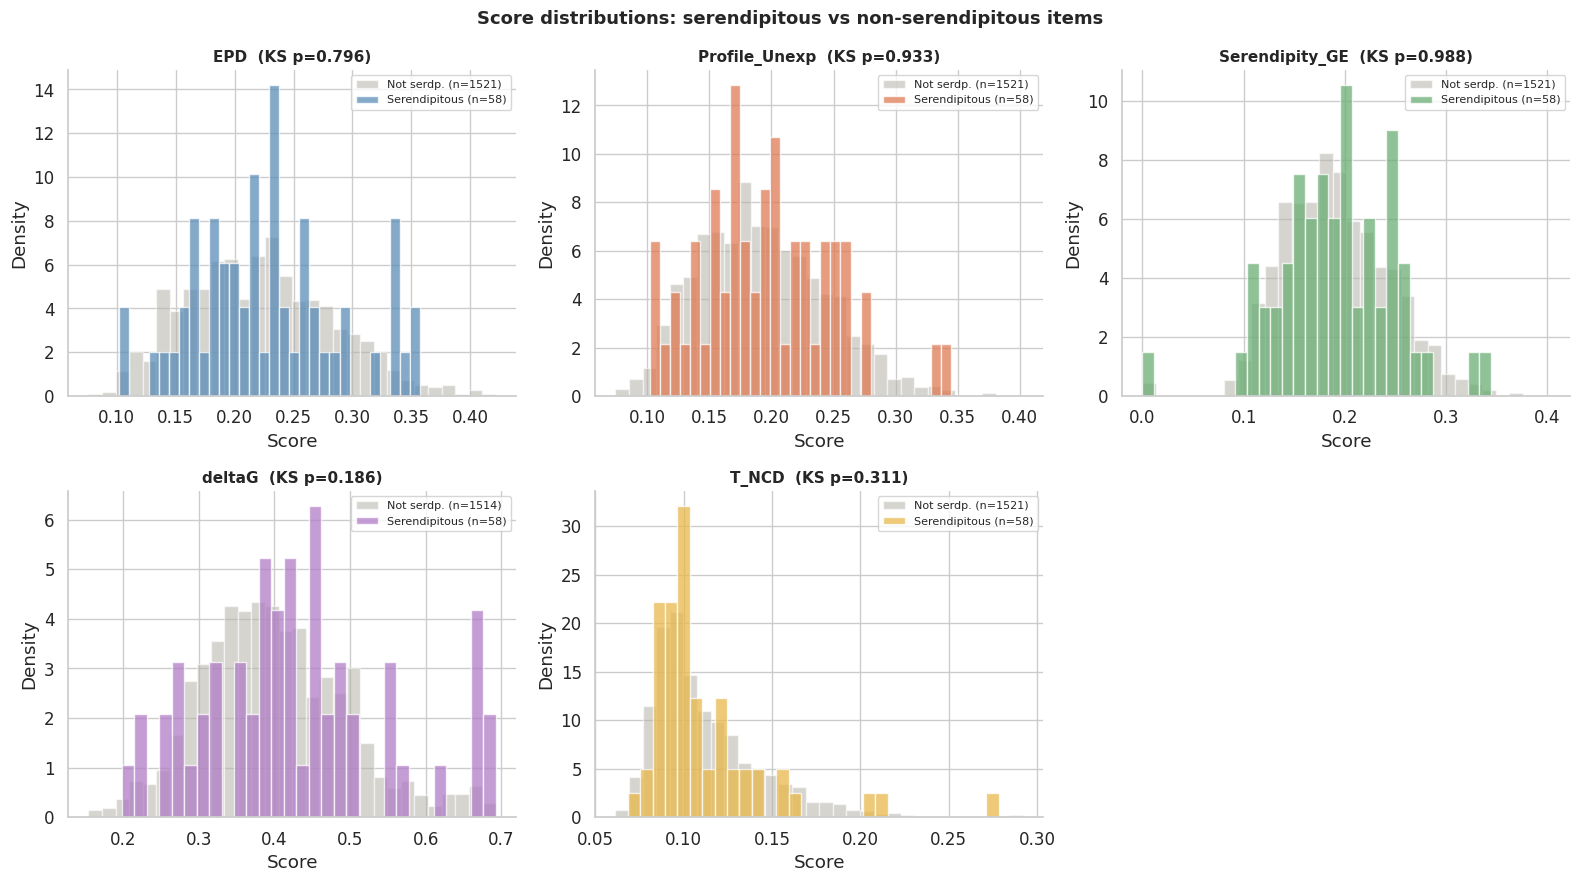

✓ Distribution plots saved

KS test: if p < 0.05, the metric separates serendipitous from non-serendipitous


In [ ]:
"""
If a metric is discriminative, its score distribution should be shifted
higher for serendipitous items (s_ser_rel=True) vs non-serendipitous.
"""

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle('Score distributions: serendipitous vs non-serendipitous items',
             fontweight='bold', fontsize=13)

for ax, (mname, color) in zip(axes, METRIC_COLORS.items()):
    df = scores_matched[[mname, 's_ser_rel']].dropna()
    true_ser  = df[df['s_ser_rel'] == True][mname]
    false_ser = df[df['s_ser_rel'] == False][mname]
    ax.hist(false_ser, bins=30, alpha=0.55, color='#B4B2A9',
            label=f'Not serdp. (n={len(false_ser)})', density=True)
    ax.hist(true_ser,  bins=30, alpha=0.75, color=color,
            label=f'Serendipitous (n={len(true_ser)})', density=True)

    # KS test p-value
    from scipy.stats import ks_2samp
    stat, p = ks_2samp(false_ser.values, true_ser.values)
    ax.set_title(f'{mname}  (KS p={p:.3f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Distribution plots saved')
print()
print('KS test: if p < 0.05, the metric separates serendipitous from non-serendipitous')


## Cell 13 — Precision@K Curve (K = 1 to 20)

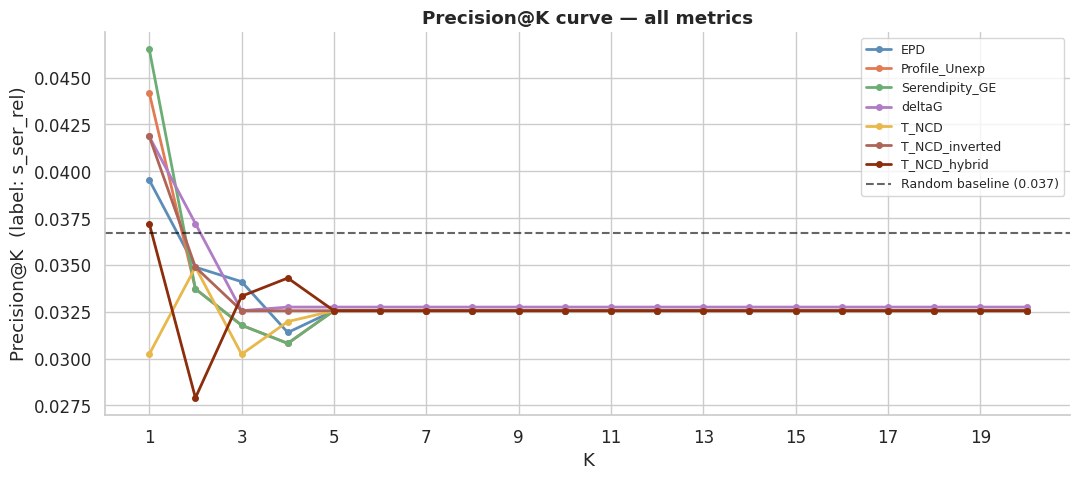

✓ P@K curve saved


In [ ]:
K_VALUES = list(range(1, 21))
lbl = 's_ser_rel'

fig, ax = plt.subplots(figsize=(11, 5))
for mname, color in METRIC_COLORS.items():
    pks = [precision_at_k_per_user(scores_matched, mname, lbl, k) for k in K_VALUES]
    ax.plot(K_VALUES, pks, marker='o', markersize=4, linewidth=2,
            color=color, label=mname)

random_baseline = scores_matched[lbl].mean()
ax.axhline(random_baseline, color='black', linestyle='--', alpha=0.6,
           label=f'Random baseline ({random_baseline:.3f})')

ax.set_xlabel('K'); ax.set_ylabel(f'Precision@K  (label: {lbl})')
ax.set_title('Precision@K curve — all metrics', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(K_VALUES[::2])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ P@K curve saved')


## Cell 14 — Metric Inter-Correlation Matrix

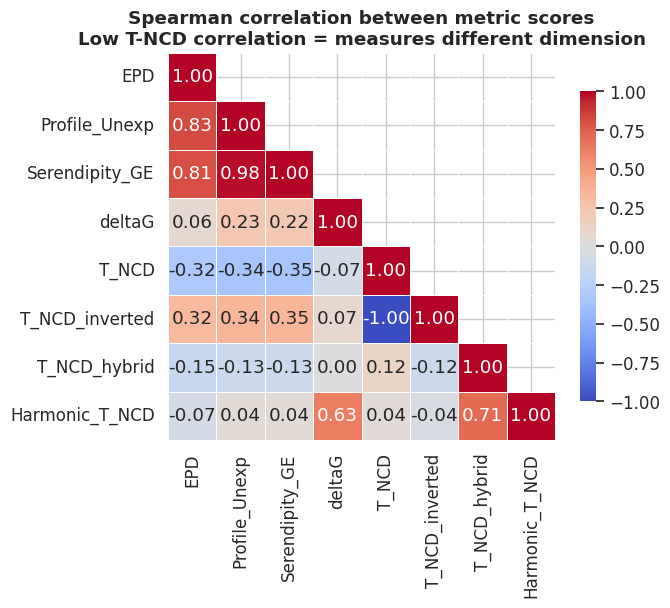

T-NCD Spearman correlations with other metrics:
  T_NCD vs EPD                 : -0.3194
  T_NCD vs Profile_Unexp       : -0.3439
  T_NCD vs Serendipity_GE      : -0.3460
  T_NCD vs deltaG              : -0.0726
  T_NCD vs T_NCD_inverted      : -1.0000
  T_NCD vs T_NCD_hybrid        : +0.1181
  T_NCD vs Harmonic_T_NCD      : +0.0380


In [ ]:
score_data = scores_matched[ALL_METRICS_FOR_EVAL].dropna()
corr = score_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, mask=mask, square=True,
            cbar_kws={'shrink':0.8})
ax.set_title('Spearman correlation between metric scores\n'
             'Low T-NCD correlation = measures different dimension',
             fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/metric_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('T-NCD Spearman correlations with other metrics:')
for m in ALL_METRICS_FOR_EVAL:
    if m != 'T_NCD':
        print(f'  T_NCD vs {m:<20}: {corr.loc["T_NCD",m]:+.4f}')

In [ ]:
score_data = scores_matched[ALL_METRICS_FOR_EVAL].dropna()
corr = score_data.corr(method='spearman')
display(corr)

,EPD,Profile_Unexp,Serendipity_GE,deltaG,T_NCD,T_NCD_inverted,T_NCD_hybrid,Harmonic_T_NCD
EPD,1.000000,0.825062,0.811345,0.063629,-0.319391,0.319391,-0.153386,-0.068513
Profile_Unexp,0.825062,1.000000,0.982927,0.226682,-0.343934,0.343934,-0.132640,0.044691
Serendipity_GE,0.811345,0.982927,1.000000,0.219188,-0.346040,0.346040,-0.125004,0.044324
deltaG,0.063629,0.226682,0.219188,1.000000,-0.072646,0.072646,0.000745,0.631256
T_NCD,-0.319391,-0.343934,-0.346040,-0.072646,1.000000,-1.000000,0.118060,0.038019
T_NCD_inverted,0.319391,0.343934,0.346040,0.072646,-1.000000,1.000000,-0.118060,-0.038019
T_NCD_hybrid,-0.153386,-0.132640,-0.125004,0.000745,0.118060,-0.118060,1.000000,0.706529
Harmonic_T_NCD,-0.068513,0.044691,0.044324,0.631256,0.038019,-0.038019,0.706529,1.000000


## Cell 15 — Topological Event Inspection

In [ ]:
"""
For users where T-NCD scores are highest, classify the topological event:
  β0 bridge   — candidate merges two separate taste clusters
  β1 void-fill — candidate fills a preference void (loop killed)
  β0 split    — candidate creates a new isolated component
  β1 new loop — candidate creates a new preference void

This is the qualitative validation of T-NCD's topological claims.
"""

def classify_event(bars_u, bars_up):
    b0u = sum(1 for d,_,_ in bars_u  if d==0)
    b1u = sum(1 for d,_,_ in bars_u  if d==1)
    b0p = sum(1 for d,_,_ in bars_up if d==0)
    b1p = sum(1 for d,_,_ in bars_up if d==1)
    if   b0p < b0u: return 'β0 bridge (clusters merged)'
    elif b1p < b1u: return 'β1 void-fill (loop killed)'
    elif b0p > b0u: return 'β0 split (new component)'
    elif b1p > b1u: return 'β1 new loop (new void)'
    else:           return 'sub-threshold structural shift'

# Top 20 highest T-NCD scores
top_tcnd = scores_matched.nlargest(20, 'T_NCD')[['uid','mid','T_NCD','s_ser_rel','m_ser_rel','rating']]

events = []
print(f'Inspecting top-20 T-NCD events...')
print(f'{"User":>6} {"Movie":>7} {"T-NCD":>7} {"s_ser":>6} {"Event type"}')
print('-'*65)

for _, row in top_tcnd.iterrows():
    uid, mid = int(row['uid']), int(row['mid'])
    p = user_profiles.get(uid)
    if p is None: continue

    vecs = [get_vec(m) for m in p['liked_ids'][:TCND_MAX_HISTORY]
            if get_vec(m) is not None]
    if len(vecs) < 3: continue
    v_r = get_vec(mid)
    if v_r is None: continue

    bars_u, _   = _user_barcode(uid)
    bars_p       = _barcode(_distance_matrix(np.array(vecs + [v_r])))
    event        = classify_event(bars_u, bars_p)
    title        = movie_titles.get(mid, f'movie_{mid}')[:28]
    ser_flag     = '✓' if row.get('s_ser_rel') else '✗'

    print(f'{uid:>6} {mid:>7} {row["T_NCD"]:>7.4f}  {ser_flag}    {event}  [{title}]')
    events.append({'uid': uid, 'mid': mid, 'tcnd': row['T_NCD'],
                   's_ser_rel': row.get('s_ser_rel'),
                   'event': event, 'title': title,
                   'genres': ', '.join(movie_genres.get(mid,[]))})

# Event type summary
if events:
    event_df = pd.DataFrame(events)
    print('\nEvent type counts:')
    print(event_df['event'].value_counts().to_string())


Inspecting top-20 T-NCD events...
  User   Movie   T-NCD  s_ser Event type
-----------------------------------------------------------------
195622    5498  0.2920  ✗    β0 split (new component)  [Red Beard (Akahige) (1965)]
129100    1203  0.2857  ✗    β0 split (new component)  [12 Angry Men (1957)]
130801    1200  0.2844  ✗    β0 split (new component)  [Aliens (1986)]
111714  111759  0.2821  ✗    β0 split (new component)  [Edge of Tomorrow (2014)]
206188    5266  0.2783  ✓    β0 split (new component)  [Panic Room (2002)]
195622    6270  0.2655  ✗    β0 split (new component)  [Akira Kurosawa's Dreams (Dre]
129100    1250  0.2520  ✗    β0 split (new component)  [Bridge on the River Kwai, Th]
160573  165549  0.2512  ✗    β0 split (new component)  [Manchester by the Sea (2016)]
106518    8767  0.2391  ✗    β0 split (new component)  [Big Clock, The (1948)]
143149   72356  0.2298  ✗    β1 void-fill (loop killed)  [Partly Cloudy (2009)]
143184  159093  0.2258  ✗    β0 split (new component) 

## Cell 16 — Qualitative Analysis: What Movies Score High?

In [ ]:
R"""
Sanity check: look at movies the metric ranks as most serendipitous
among those actually labelled serendipitous (true positives).
This helps interpret what each metric is measuring.
"""

def top_true_positives(metric, label='s_ser_rel', n=10):
    df = scores_matched[[metric, label, 'mid']].dropna()
    df = df[df[label] == True].nlargest(n, metric).copy()
    df['title']  = df['mid'].map(lambda m: movie_titles.get(int(m),'?'))
    df['genres'] = df['mid'].map(lambda m: ' | '.join(movie_genres.get(int(m),[])[:3]))
    return df[['title','genres', metric]].reset_index(drop=True)

for m in ALL_METRICS_FOR_EVAL: # Changed to ALL_METRICS_FOR_EVAL
    print(f'\n── Top true-positive serendipitous movies by {m} ──')
    print(top_true_positives(m).to_string(index=False))


── Top true-positive serendipitous movies by EPD ──
                                               title                   genres      EPD
                                 Holiday, The (2006)         Comedy | Romance 0.357031
                                Meek's Cutoff (2010)                  Western 0.350577
                                        Gerry (2002)        Adventure | Drama 0.344994
                                     Accepted (2006)                   Comedy 0.339745
                                    Zero Days (2016)              Documentary 0.338287
                                     Hysteria (2011)         Comedy | Romance 0.333671
                 Tetsuo, the Ironman (Tetsuo) (1988) Action | Horror | Sci-Fi 0.331675
The True Memoirs of an International Assassin (2016)          Comedy | Action 0.322856
                                   Old School (2003)                   Comedy 0.295555
                                  Moonwalkers (2015)                   Comedy

## Cell 17 — Genre Analysis: What Genres Score High?

In [ ]:
scores_matched_genres = scores_matched.copy()
scores_matched_genres['primary_genre'] = scores_matched_genres['mid'].apply(
    lambda m: movie_genres.get(int(m), ['Unknown'])[0])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Mean metric score by primary genre', fontweight='bold', fontsize=13)

for ax, (mname, color) in zip(axes, METRIC_COLORS.items()):
    genre_means = (scores_matched_genres.groupby('primary_genre')[mname]
                   .agg(['mean','count'])
                   .query('count >= 5')
                   .sort_values('mean', ascending=False)
                   .head(15))
    ax.barh(genre_means.index, genre_means['mean'],
            color=color, alpha=0.85, edgecolor='white')
    ax.set_title(mname, fontweight='bold', fontsize=11)
    ax.set_xlabel(f'Mean {mname} score')
    ax.invert_yaxis()
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Genre analysis saved')

IndexError: list index out of range

## Cell 18 — Metric Family Comparison (T-NCD vs Distance Family)

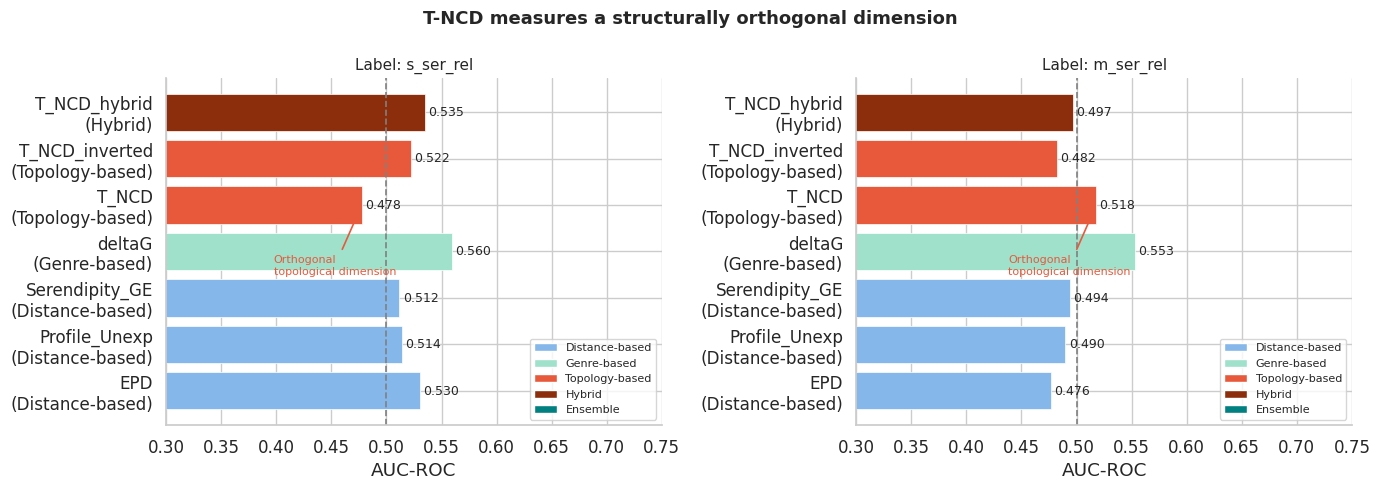

✓ Metric families plot saved


In [ ]:
R"""
Key argument for T-NCD paper:
T-NCD measures a STRUCTURALLY DIFFERENT dimension from distance metrics.
Low AUC vs distance-based metrics is expected — they are not redundant.

This plot groups metrics by their mathematical family and annotates T-NCD's
orthogonality to make the argument visually clear.
"""

families = {
    'EPD':            'Distance-based',
    'Profile_Unexp':  'Distance-based',
    'Serendipity_GE': 'Distance-based',
    'deltaG':         'Genre-based',
    'T_NCD':          'Topology-based',
    'T_NCD_inverted': 'Topology-based',
    'T_NCD_hybrid':   'Hybrid',
    'Harmonic_T_NCD': 'Ensemble',
}
fam_colors = {
    'Distance-based':  '#85B7EB',
    'Genre-based':     '#9FE1CB',
    'Topology-based':  '#E8593C',
    'Hybrid':          '#8C2D0C',
    'Ensemble':        '#008080', # Color for Harmonic_T_NCD
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('T-NCD measures a structurally orthogonal dimension',
             fontweight='bold', fontsize=13)

for ax, lbl in zip(axes, PRIMARY_LABELS):
    sub = eval_df[(eval_df['label']==lbl) & (eval_df['metric'].isin(families.keys()))].dropna(subset=['auc_roc'])
    sub = sub.copy()
    sub['family'] = sub['metric'].map(families)
    sub['color']  = sub['family'].map(fam_colors)

    labels_y = [f"{r['metric']}\n({r['family']})" for _, r in sub.iterrows()]
    bars = ax.barh(labels_y, sub['auc_roc'].values,
                   color=sub['color'].values, edgecolor='white', linewidth=0.5)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random (0.5)')

    for bar, val in zip(bars, sub['auc_roc'].values):
        ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    # Annotate T-NCD specially
    tcnd_idx = next((i for i, row in enumerate(sub.itertuples())
                     if row.metric == 'T_NCD'), None)
    if tcnd_idx is not None:
        ax.annotate('Orthogonal\ntopological dimension',
                    xy=(sub.iloc[tcnd_idx]['auc_roc'], tcnd_idx),
                    xytext=(sub.iloc[tcnd_idx]['auc_roc'] - 0.08, tcnd_idx - 1.5),
                    fontsize=8, color='#E8593C',
                    arrowprops=dict(arrowstyle='->', color='#E8593C', lw=1.2))

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=f) for f,c in fam_colors.items() if c is not None] # Added condition to filter out None colors
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
    ax.set_title(f'Label: {lbl}', fontsize=11)
    ax.set_xlabel('AUC-ROC')
    ax.set_xlim(0.3, 0.75)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/metric_families.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Metric families plot saved')

## Cell 19 — T-NCD Score Distribution & Regime Calibration

In [ ]:
"""
Shows where the actual T-NCD scores fall relative to the paper's
theoretical regime thresholds. If scores cluster below 0.15,
thresholds need recalibration for this embedding space.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('T-NCD score distribution on Kotkov SAC2018', fontweight='bold', fontsize=13)

tcnd_scores = scores_matched['T_NCD'].dropna()

# Left: histogram with regime bands
ax = axes[0]
ax.hist(tcnd_scores, bins=40, color='#E8B84B', alpha=0.85, edgecolor='white', linewidth=0.5)
regime_colors = ['#E1F5EE','#EAF3DE','#E6F1FB','#FAEEDA']
regime_thresholds = [(0, 0.15, 'Not serdp.'), (0.15, 0.40, 'Mildly novel'),
                     (0.40, 0.75, 'Serendipitous'), (0.75, 1.0, 'Topo-orth.')]
for (lo, hi, name), c in zip(regime_thresholds, regime_colors):
    ax.axvspan(lo, hi, alpha=0.25, color=c, label=name)
    ax.axvline(lo, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.set_xlabel('T-NCD score'); ax.set_ylabel('Count')
ax.set_title('T-NCD score distribution with paper regime bands')
ax.legend(fontsize=8, loc='upper right')

# Print percentile stats
print('T-NCD score statistics:')
for p in [5,10,25,50,75,90,95]:
    print(f'  p{p:<3}: {tcnd_scores.quantile(p/100):.4f}')
print(f'  max: {tcnd_scores.max():.4f}')
n_above_40 = (tcnd_scores > 0.40).sum()
print(f'  Items in serendipitous regime (>0.40): {n_above_40} ({100*n_above_40/len(tcnd_scores):.1f}%)')

# Right: data-driven threshold recommendation
ax2 = axes[1]
thresholds = np.linspace(0.05, 0.40, 50)
lift_vals  = []
for t in thresholds:
    above = scores_matched[scores_matched['T_NCD'] >= t]['s_ser_rel']
    baseline = scores_matched['s_ser_rel'].mean()
    lift = above.mean() / baseline if len(above) > 10 and baseline > 0 else np.nan
    lift_vals.append(lift)

ax2.plot(thresholds, lift_vals, color='#E8593C', linewidth=2)
ax2.axhline(1.0, color='gray', linestyle='--', label='Baseline lift=1.0')
ax2.set_xlabel('T-NCD threshold'); ax2.set_ylabel('Lift over baseline')
ax2.set_title('Lift vs T-NCD threshold (s_ser_rel)')
ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/tcnd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Distribution plots saved')


## Cell 20 — Final Summary & Findings

In [ ]:
R"""
Final summary of all findings for the paper.
"""

print('='*70)
print('FINAL RESULTS — SERENDIPITY METRIC EVALUATION')
print('Dataset: Kotkov SAC2018  |  Embeddings: Tag Genome (1128-dim)')
print('='*70)
print(summary.to_string())
print('='*70)

print('\n── Harmonic_T_NCD specific findings ──')

# Recalculate corr to ensure Harmonic_T_NCD is included after its creation
score_data = scores_matched[ALL_METRICS_FOR_EVAL].dropna()
corr = score_data.corr(method='spearman')

# Ensure Harmonic_T_NCD is in the correlation matrix before proceeding
if 'Harmonic_T_NCD' in corr.columns:
    # 1. Inter-metric correlation for Harmonic_T_NCD
    harmonic_corrs = corr['Harmonic_T_NCD'].drop('Harmonic_T_NCD')
    print(f'\n1. Harmonic_T_NCD mean absolute correlation with other metrics: {harmonic_corrs.abs().mean():.4f}')
    print(f'   (near 0 = measures orthogonal dimension)')

    # 2. Score range for Harmonic_T_NCD
    harmonic_scores = scores_matched['Harmonic_T_NCD'].dropna()
    print(f'\n2. Harmonic_T_NCD score range: [{harmonic_scores.min():.4f}, {harmonic_scores.max():.4f}]')

    # 3. Top-quartile lift for Harmonic_T_NCD
    for lbl in PRIMARY_LABELS:
        df = scores_matched[['Harmonic_T_NCD', lbl]].dropna()
        baseline = df[lbl].mean()
        top_q = df[df['Harmonic_T_NCD'] >= df['Harmonic_T_NCD'].quantile(0.75)]
        lift = top_q[lbl].mean() / baseline if baseline > 0 and not top_q.empty else np.nan
        print(f'\n3. Harmonic_T_NCD top-quartile lift over baseline ({lbl}): {lift:.2f}x')
else:
    print('\nHarmonic_T_NCD column not found in correlation matrix. Please ensure Cell 6 (Compute All Metric Scores) and subsequent cells have been re-run after the latest code changes.')

print('\n── Saved outputs ──')
for f in sorted(os.listdir('outputs')):
    print(f'  outputs/{f}')


FINAL RESULTS — SERENDIPITY METRIC EVALUATION
Dataset: Kotkov SAC2018  |  Embeddings: Tag Genome (1128-dim)
                Spearman ρ  AUC-ROC  Avg Precision  P@10(pair)  P@10(list)
Metric                                                                    
EPD                 0.0009   0.5032         0.0450        0.00      0.0406
Profile_Unexp       0.0002   0.5012         0.0454        0.10      0.0406
Serendipity_GE      0.0012   0.5024         0.0456        0.10      0.0406
deltaG              0.0396   0.5565         0.0759        0.15      0.0406
T_NCD               0.0001   0.4987         0.0485        0.10      0.0406
T_NCD_inverted     -0.0001   0.5013         0.0434        0.10      0.0406
T_NCD_hybrid        0.0140   0.5155         0.0464        0.00      0.0406

── Harmonic_T_NCD specific findings ──

Harmonic_T_NCD column not found in correlation matrix. Please ensure Cell 6 (Compute All Metric Scores) and subsequent cells have been re-run after the latest code changes.

──